## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/cloudless_mosaic/  
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)  
Conversion: Development Seed (openEO-UDP project)


# Cloudless Mosaic and OpenEO

This notebook demonstrates how to build a cloudless mosaic from Sentinel-2 L2A data over a chosen time window (e.g. 6 months or 1 year). The underlying logic follows the [Sentinel Hub cloudless mosaic evalscript](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/cloudless_mosaic/): it uses the **Scene Classification Layer (SCL)** to keep only valid, non-cloudy pixels, then for each output pixel takes the first quartile of valid reflectance values per band (B04, B03, B02 for R, G, B). If no valid pixels exist, it falls back to the first quartile of “invalid” (e.g. cloudy) values; if there are no values at all, the pixel is set to zero. Because the script aggregates many acquisitions (the original evalscript uses one year of data), processing can be compute- and time-intensive. It is recommended to use a small area (e.g. 256×256 px). It is recommended to balance the length of the acquisition period, the completeness of the result, and the spatial extent. When using SCL, nearest-neighbour resampling at about 20 m/px or coarser is important so that the classification labels are not blurred. An example of the kind of result is New Zealand’s 10 m cloudless mosaic, available at: [NZ 10m Satellite Imagery 2017](https://data.linz.govt.nz/layer/93652-nz-10m-satellite-imagery-2017/).

## Overview

In this notebook we will:
1. Connect to an OpenEO backend
2. Define an area of interest (e.g. a small region)
3. Load Sentinel-2 L2A data (with SCL) over a chosen period
4. Apply the cloudless-mosaic logic (SCL-based validation, first-quartile per band)
5. Export and visualise the cloud-free RGB mosaic

## How the cloudless mosaic works in the Evalscript

- **Input**: Sentinel-2 L2A with bands **B04** (red), **B03** (green), **B02** (blue) and **SCL** (scene classification) over three months.
- **Validation**: Only pixels with positive values and are passing the SCL/cloud check are “valid”. Excluded are: cloud shadow (3), high/medium cloud probability (9, 8), thin cirrus (10), snow/ice (11), saturated/defective (1). Optionally, low cloud probability (7) and dark feature shadow (2) can be excluded. This process creates valid and invalid arrays with values over a time period of three months. This means each valid and invalid array has x, y, band, and time dimensions.
- **Time dimension reduction**: For each pixel, valid reflectance values over the time window are collected per band, sorted, and the **first quartile** is taken (separately for R, G, B). 
- **Mosaicking**: If there are no valid values, the first quartile of invalid values is used; if there are none, the pixel is set to 0.
- **Output**: A single RGB composite representing a cloud-free view of the area over the selected period.

## Modifications to be made for translating the Evalscript to OpenEO UDP
- All other steps remain the same as in the Evalscript reference, except the time dimension reduction
- **Time dimension reduction**: Instead of taking the first quartile of each band, we're taking the median values over the three months period for each band. 


In [2]:
import openeo
import matplotlib.pyplot as plt
import rioxarray as rx
import xarray as xr
from datetime import datetime, timedelta
from PIL import Image
from openeo.processes import neq, and_, array_create, not_, if_, gt

## Connect to OpenEO-Titiler Backend

Connect to the OpenEO backend and authenticate using OpenID Connect.

In [2]:
# connection = openeo.connect(
#     url="https://api.explorer.eopf.copernicus.eu/openeo"
# ).authenticate_oidc_authorization_code()

In [4]:
connection = openeo.connect(
    url="https://openeo.dataspace.copernicus.eu/"
).authenticate_oidc()

Authenticated using refresh token.


# Define Area of Interest

Define the spatial extent for our analysis. This example uses coordinates for an area in Central Portugal

In [4]:
spatial_extent = {"west" : 12.3793, "south" : 45.8996, "east" : 12.7918, "north" : 46.1364}

## Load Sentinel-2 Data

Load Sentinel-2 L2A (bottom-of-atmosphere reflectance) data. We need multiple bands:

- **B04** (Red, 664.6 nm): Red band
- **B03** (Green, 559.8 nm): Green band
- **B02** (Blue, 492.4 nm): Blue band
- **SCL**: Scene classification data with the following classification:
    - 0 - No data
    - 1 - Saturated / Defective
    - 2 - Dark Area Pixels
    - 3 - Cloud Shadows
    - 4 - Vegetation
    - 5 - Bare Soils
    - 6 - Water
    - 7 - Clouds low probability / Unclassified
    - 8 - Clouds medium probability
    - 9 - Clouds high probability
    - 10 - Cirrus
    - 11 - Snow / Ice

In [5]:
end_date = "2025-11-30"  
end_dt = datetime.strptime(end_date, "%Y-%m-%d")
start_dt = end_dt - timedelta(days=1 * 14) 
start_date = start_dt.strftime("%Y-%m-%d")

print(f"Loading data from {start_date} to {end_date}")

s2cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=[start_date, end_date],
    bands=[
        "B02",
        "B03",
        "B04",
        "SCL"
    ],
)

Loading data from 2025-11-16 to 2025-11-30


In [6]:
# Exclude 0, 1, 3, 8, 9, 10, 11
def validate(scl_band):
    return and_(
        neq(scl_band, 3),
        and_(
            neq(scl_band, 9),
            and_(
                neq(scl_band, 8),
                and_(
                    neq(scl_band, 10),
                    and_(
                        neq(scl_band, 11),
                        and_(
                            neq(scl_band, 1),
                            neq(scl_band, 0)
                        )
                    )
                )
            )
        )
    )

In [7]:
# Step 1: At each (x,y,t) output 6 bands: [valid_R, valid_G, valid_B, invalid_R, invalid_G, invalid_B].
from openeo.processes import create_data_cube


def mask_valid_invalid(data):
    B02, B03, B04, SCL = (
        data[0], 
        data[1], 
        data[2], 
        data[3]
    )
    
    B02 = B02 / 10000
    B03 = B03 / 10000
    B04 = B04 / 10000

    positive = and_(gt(B02, 0), and_(gt(B03, 0), gt(B04, 0)))
    mask = validate(SCL)
    isValid = and_(positive, mask)
    inValid = and_(positive, not_(mask))

    valid_cube = create_data_cube()

    def create_val(data):
        return array_create([
            if_(isValid, B04, None), if_(isValid, B03, None), if_(isValid, B02, None),
        ])

    valid_cube = valid_cube.add_dimension("t", "time", "t")
    valid_cube = valid_cube.apply_dimension(dimension="t", process=create_val)
    valid_reducer = valid_cube.reduce_dimension(dimension="t", reducer="median")

    # invalid_with_values = array_create([
    #     if_(inValid, B04, None), if_(inValid, B03, None), if_(inValid, B02, None),
    # ])
    # invalid_reducer = invalid_with_values.reduce_dimension(dimension="t", reducer="median")

    # valid_red = array_element(valid_reducer, 2)
    # valid_green = array_element(valid_reducer, 1)
    # valid_blue = array_element(valid_reducer, 0)

    # invalid_red = array_element(invalid_reducer, 2)
    # invalid_green = array_element(invalid_reducer, 1)
    # invalid_blue = array_element(invalid_reducer, 0)

    # final_red = if_(
    #     valid_reducer,
    #     valid_red,
    #     invalid_red
    # )

    # final_green = if_(
    #     valid_reducer,
    #     valid_green,
    #     invalid_green
    # )

    # final_blue = if_(
    #     valid_reducer,
    #     valid_blue,
    #     invalid_blue
    # )

    # R=B04, G=B03, B=B02 (index 2,1,0). Use null for no-data; median reducer ignores nulls.
    return valid_reducer

cloudless_mosaic = s2cube.apply_dimension(dimension="bands", process=mask_valid_invalid)

In [8]:
cloudless_mosaic = cloudless_mosaic.save_result("GTiff")

In [9]:
# The process doesn't work, give an error: Unsupported operation: create_data_cube (arguments: [])
cloudless_mosaic.download("cloudless_try_2.tif")

OpenEoApiError: [500] Internal: Unexpected error during 'apply_dimension': java.lang.IllegalArgumentException: Unsupported operation: create_data_cube (arguments: []). The process had these arguments: {'data': GeopysparkDataCube(metadata=GeopysparkCubeMetadata(dimension_names=['x', 'y', 't', 'bands'], band_names=['B02', 'B03', 'B04', 'SCL'])), 'dimension': 'bands', 'process': {'process_graph': {'createdatacube1': {'process_id': 'create_data_cube', 'arguments': {}}, 'adddimension1': {'process_id': 'add_dimension', 'arguments': {'data': {'from_node': 'createdatacube1', 'node': {'process_id': 'create_data_cube', 'arguments': {}}}, 'label': 'time', 'name': 't', 'type': 't'}}, 'applydimension1': {'process_id': 'apply_dimension', 'arguments': {'data': {'from_node': 'adddimension1', 'node': {'process_id': 'add_dimension', 'arguments': {'data': {'from_node': 'createdatacube1', 'node': {'process_id': 'create_data_cube', 'arguments': {}}}, 'label': 'time', 'name': 't', 'type': 't'}}}, 'dimension

## Try masking out the selected clouds from SCL band using xarray

In [9]:
# Checking how the raw data looks like before masking for clouds and negative values
spatial_extent = {"west" : 12.3793, "south" : 45.8996, "east" : 12.7918, "north" : 46.1364}

end_date = "2025-11-30"  
end_dt = datetime.strptime(end_date, "%Y-%m-%d")
start_dt = end_dt - timedelta(days=1 * 14) 
start_date = start_dt.strftime("%Y-%m-%d")

print(f"Loading data from {start_date} to {end_date}")

s2cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=[start_date, end_date],
    bands=[
        "B02",
        "B03",
        "B04",
        "SCL"
    ],
)

s2cube = s2cube.reduce_dimension(dimension="t", reducer="median")

s2cube.download("raw_data.tif")

Loading data from 2025-11-16 to 2025-11-30


In [11]:
# Band orders: B02, B03, B04, SCL
raw_data = rx.open_rasterio("raw_data.tif")

# Rescale by dividing with 10000
r = raw_data.sel(band=3) / 10000
g = raw_data.sel(band=2) / 10000
b = raw_data.sel(band=1) / 10000

# Positive mask for rgb
r = r.where(r > 0)
g = g.where(g > 0)
b = b.where(b > 0)

raw_data_scaled = xr.concat([r, g, b], dim="band")

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0739240506329115..1.0].


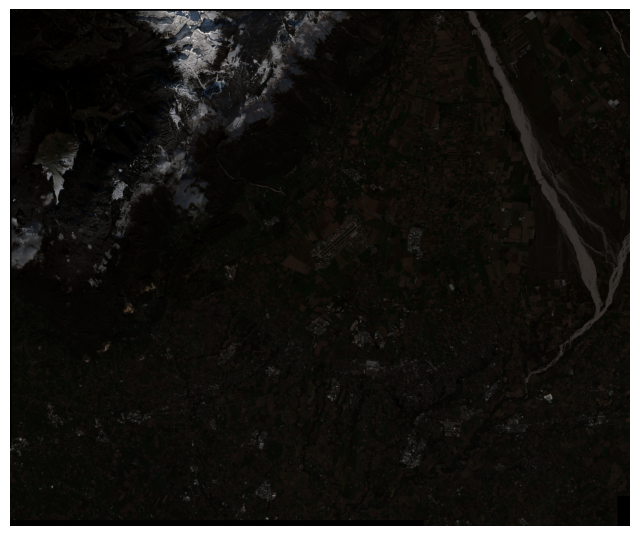

In [12]:
# RGB layer before masking the cloud and negative values (or dark colors)
rgb_layer = xr.concat([raw_data.sel(band=3), raw_data.sel(band=2), raw_data.sel(band=1)], dim="band")
rgb = rgb_layer.transpose('y', 'x', 'band').values

# optional: scale to 0–1 for display if needed
rgb = rgb / rgb.max()

plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.axis('off')
plt.show()

In [13]:
# Remove nodata label in SCL band
scl = raw_data.sel(band=4)
scl = scl.where(scl > 0)

# Remove clouds
scl_invalid = [1, 3, 8, 9, 10, 11]
valid_mask = ~scl.isin(scl_invalid)

# Apply mask 
raw_data_masked = raw_data_scaled.where(valid_mask)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0001..1.53].


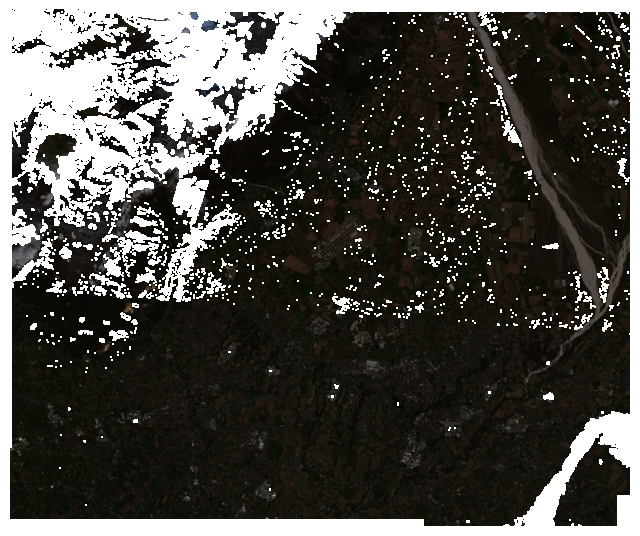

In [14]:
# RGB layer after masking the negative values and cloud. This is the expected result from the UDP that masks negative values and cloud
# Without merging valid and invalid arrays during the mosaicking process
rgb_layer = xr.concat([raw_data_masked.sel(band=3), raw_data_masked.sel(band=2), raw_data_masked.sel(band=1)], dim="band")
rgb = rgb_layer.transpose('y', 'x', 'band').values

plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.axis('off')
plt.show()

### Older UDP that masks out clouds and negative values

In [16]:
spatial_extent = {"west" : 12.3793, "south" : 45.8996, "east" : 12.7918, "north" : 46.1364}

end_date = "2025-11-30"  
end_dt = datetime.strptime(end_date, "%Y-%m-%d")
start_dt = end_dt - timedelta(days=1 * 14) 
start_date = start_dt.strftime("%Y-%m-%d")

print(f"Loading data from {start_date} to {end_date}")

s2cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=[start_date, end_date],
    bands=[
        "B02",
        "B03",
        "B04",
        "SCL"
    ],
)

Loading data from 2025-11-16 to 2025-11-30


In [17]:
# Exclude 0, 1, 3, 8, 9, 10, 11
def validate(scl_band):
    return and_(
        neq(scl_band, 3),
        and_(
            neq(scl_band, 9),
            and_(
                neq(scl_band, 8),
                and_(
                    neq(scl_band, 10),
                    and_(
                        neq(scl_band, 11),
                        and_(
                            neq(scl_band, 1),
                            neq(scl_band, 0)
                        )
                    )
                )
            )
        )
    )

In [18]:
def mask_valid_invalid(data):
    B02, B03, B04, SCL = (
        data[0], 
        data[1], 
        data[2], 
        data[3]
    )
    
    B02 = B02 / 10000
    B03 = B03 / 10000
    B04 = B04 / 10000

    positive = and_(gt(B02, 0), and_(gt(B03, 0), gt(B04, 0)))
    mask = validate(SCL)
    isValid = and_(positive, mask)
    
    return array_create([
        if_(isValid, B04, None), if_(isValid, B03, None), if_(isValid, B02, None)
    ])

cloudless_mosaic = s2cube.apply_dimension(dimension="bands", process=mask_valid_invalid)
cloudless_mosaic = cloudless_mosaic.reduce_dimension(dimension="t", reducer="median")
cloudless_mosaic = cloudless_mosaic.save_result("GTiff")
cloudless_mosaic.download("cloudless_try.tif")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1e-04..1.8248].


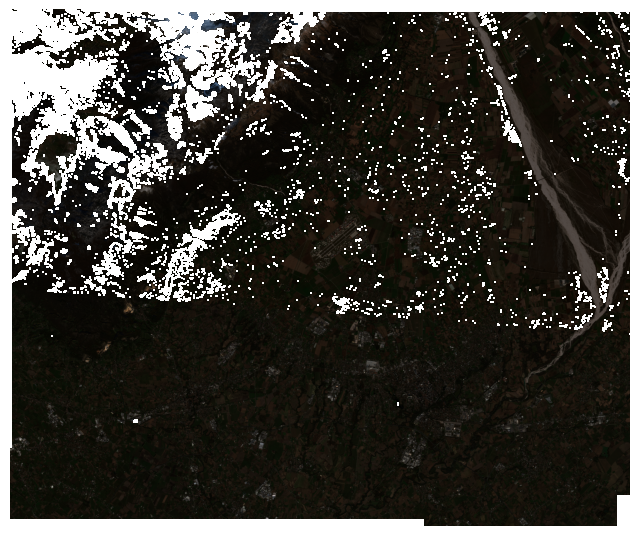

In [19]:
# B02, B03, B04, SCL from openEO (masking cloud and including only positive values)
# This is the expected result from UDP that only masks clouds and negative values, but without the merging between valid and invalid arrays in the mosaicking process
cloudless_try = rx.open_rasterio("cloudless_try.tif")

# RGB layer before masking the cloud and negative values
rgb_layer = xr.concat([cloudless_try.sel(band=1), cloudless_try.sel(band=2), cloudless_try.sel(band=3)], dim="band")
rgb = rgb_layer.transpose('y', 'x', 'band').values

plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.axis('off')
plt.show()